<Axes: xlabel='credit_risk', ylabel='count'>

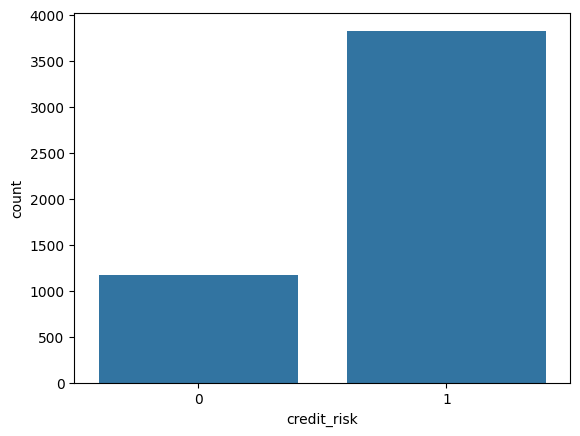

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df=pd.read_csv(r"C:\Users\AS\Downloads\archive(5)\credit_risk_dataset.csv")
df['credit_risk'].value_counts()

sns.countplot(data=df, x='credit_risk')

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'annual_income'}>,
        <Axes: title={'center': 'account_age_months'}>,
        <Axes: title={'center': 'avg_monthly_balance'}>],
       [<Axes: title={'center': 'num_deposits_per_month'}>,
        <Axes: title={'center': 'avg_deposit_amount'}>,
        <Axes: title={'center': 'debit_card_usage_frequency'}>,
        <Axes: title={'center': 'debit_card_spending'}>],
       [<Axes: title={'center': 'mobile_banking_logins'}>,
        <Axes: title={'center': 'online_transfer_frequency'}>,
        <Axes: title={'center': 'atm_withdrawal_frequency'}>,
        <Axes: title={'center': 'credit_score'}>],
       [<Axes: title={'center': 'num_open_loans'}>,
        <Axes: title={'center': 'total_outstanding_debt'}>,
        <Axes: title={'center': 'late_payment_count'}>,
        <Axes: title={'center': 'loan_default_history'}>],
       [<Axes: title={'center': 'fraud_flag'}>,
        <Axes: title={'center': 'loan_applicat

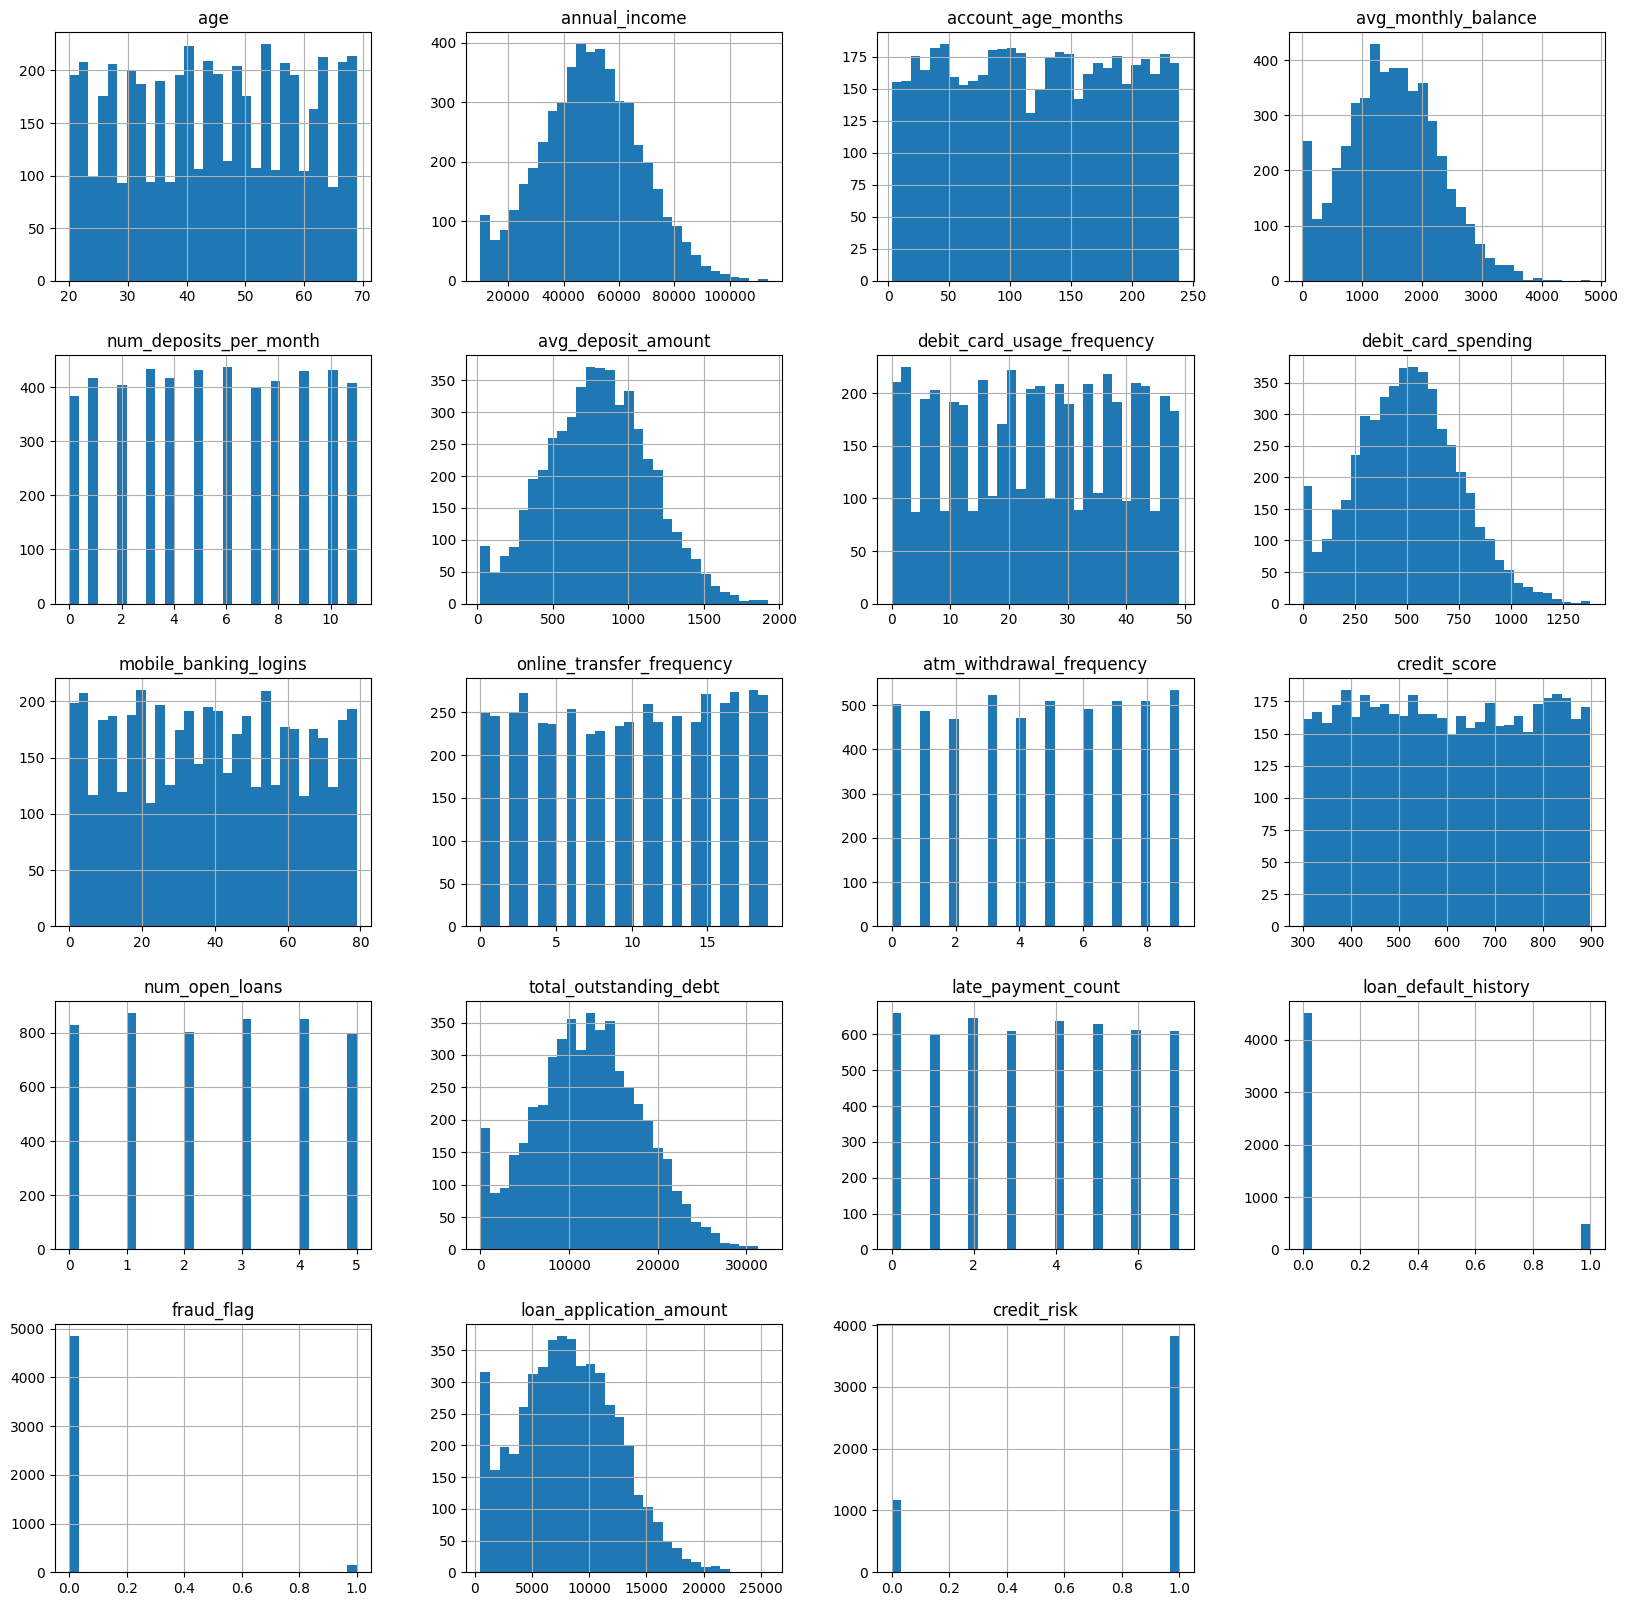

In [2]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
df[num_cols].hist(figsize=(20,20), bins=30)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# الأعمدة النصية
cat_cols = df.select_dtypes(include='object').columns.tolist()

# حذف الأعمدة النصية والـ Target من الـ Features
X = df.drop(columns=['credit_risk'] + cat_cols)
X = X.drop(columns=["late_payment_count", "credit_score"])

# الـ Target
y = df['credit_risk']

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # يحافظ على نفس نسبة الفئات في Train و Test
)

# إنشاء النموذج
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# تدريب النموذج
model.fit(X_train, y_train)

# التنبؤ
y_pred = model.predict(X_test)

# حساب الـ Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.7580
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       234
           1       0.76      0.99      0.86       766

    accuracy                           0.76      1000
   macro avg       0.38      0.49      0.43      1000
weighted avg       0.59      0.76      0.66      1000



In [7]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                       Feature  Importance
14          late_payment_count    0.419607
11                credit_score    0.393471
15        loan_default_history    0.063691
16                  fraud_flag    0.015532
1                annual_income    0.009954
3          avg_monthly_balance    0.009926
5           avg_deposit_amount    0.009557
17     loan_application_amount    0.009505
7          debit_card_spending    0.009497
2           account_age_months    0.009425
13      total_outstanding_debt    0.009249
6   debit_card_usage_frequency    0.007555
8        mobile_banking_logins    0.007523
0                          age    0.006956
9    online_transfer_frequency    0.006194
4       num_deposits_per_month    0.005060
10    atm_withdrawal_frequency    0.004111
12              num_open_loans    0.003186
